# # Noise vs. True-Token Rank
#
# This notebook explores how the rank of the true token changes as noise is
# added to its embedding, following the DiffuSeq forward (noising) process.
#
# **Goal**
# - Find the shape of how fast the true token becomes "too far" from its
#   noised version.
# - Identify noise ranges where repetition codes would be useful (i.e. where
#   rank is still low enough that redundancy could recover the token).
#
# **Measure**: MSE distance from the noised embedding to every row of the
# embedding matrix.
#
# **Embeddings**: BERT's pretrained word-embedding matrix
# (`bert-base-uncased`), via its tokenizer/vocab.
#
# **Noise**: DiffuSeq's `q_sample` forward process,
#   x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * noise
# where `alpha_cumprod_t` comes from a beta schedule. You can choose the
# schedule (`raw`, `linear`, `cosine`, `sqrt`) as a parameter — `raw` skips
# the schedule entirely and lets you sweep a noise std directly.


In [43]:
import math
import numpy as np
import os, torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

torch.set_num_threads(os.cpu_count())   # put this near the top of the notebook, before any torch ops

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

def betas_for_alpha_bar(num_diffusion_timesteps, alpha_bar_fn, max_beta=0.999):
    betas = []
    for i in range(num_diffusion_timesteps):
        t1 = i / num_diffusion_timesteps
        t2 = (i + 1) / num_diffusion_timesteps
        betas.append(min(1 - alpha_bar_fn(t2) / alpha_bar_fn(t1), max_beta))
    return np.array(betas)


def get_named_beta_schedule(schedule_name, num_diffusion_timesteps):
    """Reproduces DiffuSeq's beta schedules (linear, cosine, sqrt)."""
    if schedule_name == "linear":
        scale = 1000 / num_diffusion_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        return np.linspace(beta_start, beta_end, num_diffusion_timesteps, dtype=np.float64)
    elif schedule_name == "cosine":
        return betas_for_alpha_bar(
            num_diffusion_timesteps,
            lambda t: math.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2,
        )
    elif schedule_name == "sqrt":
        return betas_for_alpha_bar(
            num_diffusion_timesteps,
            lambda t: 1 - np.sqrt(t + 0.0001),
        )
    else:
        raise NotImplementedError(f"unknown beta schedule: {schedule_name}")


def get_alpha_cumprod(schedule, num_timesteps):
    """
    Returns alphas_cumprod (length num_timesteps) for a given schedule name.
    schedule: 'linear' | 'cosine' | 'sqrt' | 'raw'

    For 'raw', there is no beta schedule — alphas_cumprod is undefined and the
    sweep should instead be driven directly over a noise-std grid (see below).
    """
    if schedule == "raw":
        return None
    betas = get_named_beta_schedule(schedule, num_timesteps)
    alphas = 1.0 - betas
    alphas_cumprod = np.cumprod(alphas, axis=0)
    return alphas_cumprod


In [44]:
def q_sample(x_start, alpha_cumprod_t=None, sigma=None, noise=None):
    """
    x_start: [..., D] clean embedding(s)
    alpha_cumprod_t: scalar float, cumulative product of (1-beta) up to t (schedule modes)
    sigma: scalar float, raw noise std (raw mode) -- mutually exclusive with alpha_cumprod_t
    noise: optional pre-sampled noise tensor, same shape as x_start
    """
    if noise is None:
        noise = torch.randn_like(x_start)

    if sigma is not None:
        assert alpha_cumprod_t is None, "pass either sigma (raw) or alpha_cumprod_t (schedule), not both"
        return x_start + sigma * noise
    else:
        assert alpha_cumprod_t is not None
        sqrt_ac = math.sqrt(alpha_cumprod_t)
        sqrt_1mac = math.sqrt(1.0 - alpha_cumprod_t)
        return sqrt_ac * x_start + sqrt_1mac * noise


def noise_std_from_alpha_cumprod(alpha_cumprod_t):
    """The effective noise std sqrt(1 - alpha_cumprod_t), DiffuSeq's convention."""
    return math.sqrt(1.0 - alpha_cumprod_t)


@torch.no_grad()
def true_token_rank(noised_vec, true_token_id, embedding_matrix):
    """
    noised_vec: [D] tensor
    true_token_id: int
    embedding_matrix: [V, D] tensor
    returns: (rank (0-indexed, lower=closer), mse_to_true_token)
    """
    # squared L2 distance (sum of squared errors); divide by D for MSE
    diffs = embedding_matrix - noised_vec.unsqueeze(0)  # [V, D]
    sq_dists = (diffs ** 2).sum(dim=-1)                  # [V]
    mse_to_true = sq_dists[true_token_id].item() / embedding_matrix.shape[1]

    sorted_ids = torch.argsort(sq_dists)                 # ascending distance
    rank = (sorted_ids == true_token_id).nonzero(as_tuple=True)[0].item()
    return rank, mse_to_true


@torch.no_grad()
def rank_sweep_for_token(
    token_id,
    embedding_matrix,
    schedule="sqrt",
    num_timesteps=2000,
    timestep_grid=None,
    sigma_grid=None,
    n_trials=10,
):
    """
    Sweeps noise level for a single token and returns per-level rank stats.

    schedule: 'linear' | 'cosine' | 'sqrt' | 'raw'
    timestep_grid: which timesteps t to evaluate (ignored if schedule == 'raw')
    sigma_grid: which raw sigma values to evaluate (only used if schedule == 'raw')
    n_trials: number of noise samples averaged per level (noise is stochastic)

    Returns a dict with parallel arrays: 't', 'sigma', 'mean_rank', 'std_rank',
    'mean_mse', 'std_mse'.
    """
    x0 = embedding_matrix[token_id]  # [D]

    results = {"t": [], "sigma": [], "mean_rank": [], "std_rank": [], "mean_mse": [], "std_mse": []}

    if schedule == "raw":
        assert sigma_grid is not None, "raw schedule requires sigma_grid"
        levels = [(None, s) for s in sigma_grid]
    else:
        alphas_cumprod = get_alpha_cumprod(schedule, num_timesteps)
        if timestep_grid is None:
            timestep_grid = np.linspace(0, num_timesteps - 1, 50).astype(int)
        levels = [(t, None) for t in timestep_grid]

    for t, sigma in levels:
        ranks, mses = [], []
        for _ in range(n_trials):
            if schedule == "raw":
                x_t = q_sample(x0, sigma=sigma)
                eff_sigma = sigma
            else:
                ac_t = alphas_cumprod[t]
                x_t = q_sample(x0, alpha_cumprod_t=ac_t)
                eff_sigma = noise_std_from_alpha_cumprod(ac_t)
            rank, mse = true_token_rank(x_t, token_id, embedding_matrix)
            ranks.append(rank)
            mses.append(mse)

        results["t"].append(t if t is not None else np.nan)
        results["sigma"].append(eff_sigma)
        results["mean_rank"].append(np.mean(ranks))
        results["std_rank"].append(np.std(ranks))
        results["mean_mse"].append(np.mean(mses))
        results["std_mse"].append(np.std(mses))

    return {k: np.array(v) for k, v in results.items()}



In [65]:
import random
import re

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
embedding_matrix = bert_model.embeddings.word_embeddings.weight.detach().to(device)  # [vocab_size, hidden_dim]
vocab_size, hidden_dim = embedding_matrix.shape
print(f"vocab_size={vocab_size}, hidden_dim={hidden_dim}")

# Keep only clean, whole alphabetic words (no subwords, no specials, no numbers, no symbols)
all_tokens = tokenizer.convert_ids_to_tokens(range(vocab_size))
clean_ids = [i for i, tok in enumerate(all_tokens) if re.fullmatch(r"[a-z]+", tok)]

sampled_ids = random.sample(clean_ids, 10000)
sampled_words = tokenizer.convert_ids_to_tokens(sampled_ids)
sampled_embeddings = embedding_matrix[sampled_ids]  # [3000, hidden_dim]

all_words = tokenizer.convert_ids_to_tokens(clean_ids)
print(sampled_words[:20])
print(sampled_embeddings.shape)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab_size=30522, hidden_dim=768
['ransom', 'furious', 'likes', 'violating', 'enter', 'cheney', 'oman', 'managing', 'yeshiva', 'vii', 'shrink', 'claire', 'improvised', 'monks', 'advisor', 'sh', 'evolved', 'orbiting', 'university', 'nucleus']
torch.Size([10000, 768])


In [47]:
import random
random.seed(0)
vocab_size

30522

In [74]:
from tqdm.auto import tqdm

SCHEDULE = "raw"  # 'raw' | 'linear' | 'cosine' | 'sqrt'
NUM_TIMESTEPS = 2000
N_TRIALS = 3
WORDS = all_words
WORD_BATCH_SIZE = 32   # lower if you hit OOM, raise if RAM is plentiful


@torch.no_grad()
def rank_sweep_batched(
    token_ids, embedding_matrix, schedule, num_timesteps,
    timestep_grid=None, sigma_grid=None, n_trials=3,
    word_batch_size=32, seed=0,
):
    dev = embedding_matrix.device
    dt = embedding_matrix.dtype
    V, D = embedding_matrix.shape

    if schedule == "raw":
        assert sigma_grid is not None
        sigmas = np.asarray(sigma_grid, dtype=np.float64)
        T = len(sigmas)
        sqrt_ac = np.ones(T, dtype=np.float64)
        sqrt_1mac = sigmas
        t_array = np.full(T, np.nan)
    else:
        ac = get_alpha_cumprod(schedule, num_timesteps)
        if timestep_grid is None:
            timestep_grid = np.linspace(0, num_timesteps - 1, 50).astype(int)
        t_array = np.asarray(timestep_grid)
        ac_vals = ac[t_array]
        sqrt_ac = np.sqrt(ac_vals)
        sqrt_1mac = np.sqrt(1.0 - ac_vals)
        sigmas = sqrt_1mac
        T = len(t_array)

    emb_sq = (embedding_matrix * embedding_matrix).sum(dim=-1)        # [V]
    sqrt_ac_t   = torch.tensor(sqrt_ac,   dtype=dt, device=dev)        # [T]
    sqrt_1mac_t = torch.tensor(sqrt_1mac, dtype=dt, device=dev)        # [T]

    gen = torch.Generator(device=dev).manual_seed(seed)
    ids_all = torch.as_tensor(token_ids, dtype=torch.long, device=dev)
    W = len(ids_all)
    N = n_trials

    mean_rank = np.zeros((W, T)); std_rank = np.zeros((W, T))
    mean_mse  = np.zeros((W, T)); std_mse  = np.zeros((W, T))

    n_chunks = (W + word_batch_size - 1) // word_batch_size
    pbar = tqdm(total=W, desc="words", unit="w")

    for ci in range(n_chunks):
        a = ci * word_batch_size
        b = min(a + word_batch_size, W)
        ids = ids_all[a:b]
        B = ids.shape[0]

        x0 = embedding_matrix[ids]                                    # [B, D]
        noise = torch.randn(B, T, N, D, dtype=dt, device=dev, generator=gen)
        x_t = (sqrt_ac_t.view(1, T, 1, 1) * x0.view(B, 1, 1, D)
               + sqrt_1mac_t.view(1, T, 1, 1) * noise)                # [B,T,N,D]
        Q = x_t.view(B * T * N, D)

        # ||q - e||^2 = ||q||^2 + ||e||^2 - 2 q.e^T
        q_sq  = (Q * Q).sum(dim=-1, keepdim=True)                     # [BTN, 1]
        cross = Q @ embedding_matrix.T                                # [BTN, V]
        sq    = q_sq + emb_sq.unsqueeze(0) - 2.0 * cross               # [BTN, V]

        true_ids = ids.view(B, 1, 1).expand(B, T, N).reshape(-1)
        d_true = sq.gather(1, true_ids.unsqueeze(1)).squeeze(1)        # [BTN]
        ranks  = (sq < d_true.unsqueeze(1)).sum(dim=-1)                # [BTN]
        mses   = d_true / D

        ranks = ranks.view(B, T, N).float()
        mses  = mses.view(B, T, N)

        mean_rank[a:b] = ranks.mean(dim=-1).cpu().numpy()
        std_rank[a:b]  = ranks.std(dim=-1).cpu().numpy()
        mean_mse[a:b]  = mses.mean(dim=-1).cpu().numpy()
        std_mse[a:b]   = mses.std(dim=-1).cpu().numpy()

        pbar.update(b - a)
    pbar.close()

    return {"t": t_array, "sigma": sigmas,
            "mean_rank": mean_rank, "std_rank": std_rank,
            "mean_mse": mean_mse,   "std_mse": std_mse}


if SCHEDULE == "raw":
    typical_norm = embedding_matrix.norm(dim=-1).mean().item()
    sigma_grid = np.linspace(0.0, typical_norm * 2, 50)
    timestep_grid = None
else:
    sigma_grid = None
    timestep_grid = np.linspace(0, NUM_TIMESTEPS - 1, 50).astype(int)

# Resolve token ids once, drop UNKs
token_ids, kept_words = [], []
for w in WORDS:
    tid = tokenizer.convert_tokens_to_ids(w)
    if tid == tokenizer.unk_token_id:
        print(f"skipping OOV: {w}")
        continue
    token_ids.append(tid)
    kept_words.append(w)

res = rank_sweep_batched(
    token_ids, embedding_matrix,
    schedule=SCHEDULE,
    num_timesteps=NUM_TIMESTEPS,
    timestep_grid=timestep_grid,
    sigma_grid=sigma_grid,
    n_trials=N_TRIALS,
    word_batch_size=WORD_BATCH_SIZE,
)

all_results = {
    w: {"t": res["t"], "sigma": res["sigma"],
        "mean_rank": res["mean_rank"][i], "std_rank": res["std_rank"][i],
        "mean_mse":  res["mean_mse"][i],  "std_mse":  res["std_mse"][i]}
    for i, w in enumerate(kept_words)
}

words: 100%|██████████| 21745/21745 [02:45<00:00, 131.39w/s]


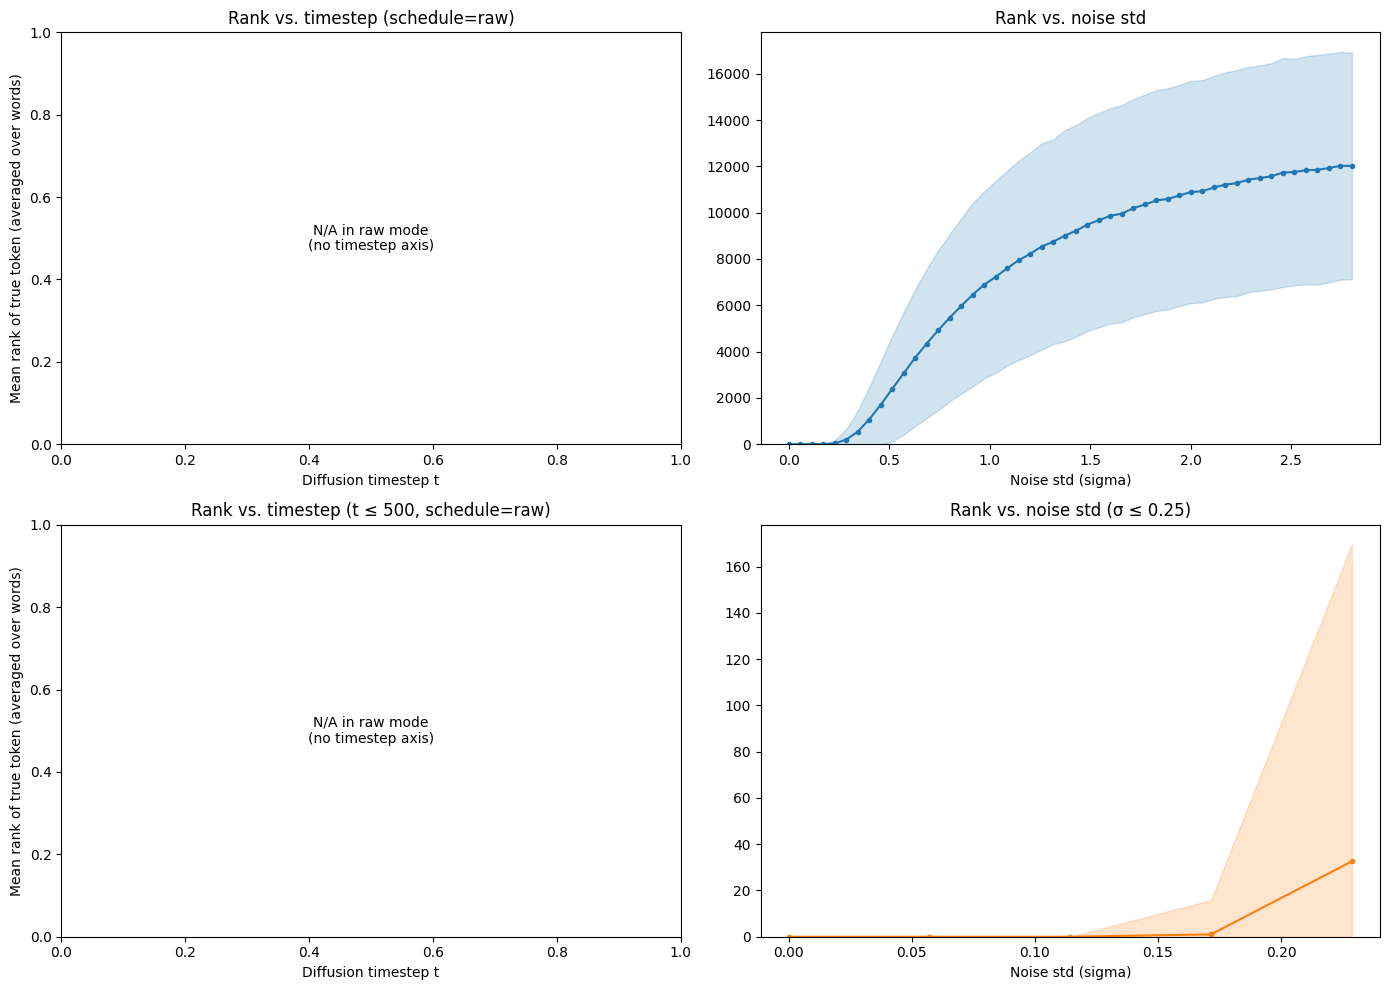

In [75]:
# Stack per-word arrays into [W, T], then average over words (axis=0)
ranks_per_word = np.stack([d["mean_rank"] for d in all_results.values()])  # [W, T]
mses_per_word  = np.stack([d["mean_mse"]  for d in all_results.values()])  # [W, T]

mean_rank_avg = ranks_per_word.mean(axis=0)   # [T]
std_rank_avg  = ranks_per_word.std(axis=0)    # [T] -- spread across words

# Lower band clipped at 0 (rank can't be negative)
lower = np.clip(mean_rank_avg - std_rank_avg, 0, None)
upper = mean_rank_avg + std_rank_avg

# Use t/sigma from any one word (they're shared across all)
first = next(iter(all_results.values()))
t_arr   = first["t"]
sig_arr = first["sigma"]

T_MAX = 500
SIGMA_MAX = 0.25
t_mask     = t_arr   <= T_MAX
sigma_mask = sig_arr <= SIGMA_MAX

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 0: full range
if SCHEDULE != "raw":
    axes[0, 0].plot(t_arr, mean_rank_avg, marker="o", markersize=3, color="C0")
    axes[0, 0].fill_between(t_arr, lower, upper, alpha=0.2, color="C0")
else:
    axes[0, 0].text(0.5, 0.5, "N/A in raw mode\n(no timestep axis)",
                    ha="center", va="center", transform=axes[0, 0].transAxes)

axes[0, 1].plot(sig_arr, mean_rank_avg, marker="o", markersize=3, color="C0")
axes[0, 1].fill_between(sig_arr, lower, upper, alpha=0.2, color="C0")

axes[0, 0].set_xlabel("Diffusion timestep t")
axes[0, 0].set_ylabel("Mean rank of true token (averaged over words)")
axes[0, 0].set_title(f"Rank vs. timestep (schedule={SCHEDULE})")
axes[0, 0].set_ylim(bottom=0)

axes[0, 1].set_xlabel("Noise std (sigma)")
axes[0, 1].set_title("Rank vs. noise std")
axes[0, 1].set_ylim(bottom=0)

# Row 1: zoomed low-noise regime
if SCHEDULE != "raw":
    axes[1, 0].plot(t_arr[t_mask], mean_rank_avg[t_mask],
                    marker="o", markersize=3, color="C1")
    axes[1, 0].fill_between(t_arr[t_mask], lower[t_mask], upper[t_mask],
                            alpha=0.2, color="C1")
else:
    axes[1, 0].text(0.5, 0.5, "N/A in raw mode\n(no timestep axis)",
                    ha="center", va="center", transform=axes[1, 0].transAxes)

axes[1, 1].plot(sig_arr[sigma_mask], mean_rank_avg[sigma_mask],
                marker="o", markersize=3, color="C1")
axes[1, 1].fill_between(sig_arr[sigma_mask], lower[sigma_mask], upper[sigma_mask],
                        alpha=0.2, color="C1")

axes[1, 0].set_xlabel("Diffusion timestep t")
axes[1, 0].set_ylabel("Mean rank of true token (averaged over words)")
axes[1, 0].set_title(f"Rank vs. timestep (t ≤ {T_MAX}, schedule={SCHEDULE})")
axes[1, 0].set_ylim(bottom=0)

axes[1, 1].set_xlabel("Noise std (sigma)")
axes[1, 1].set_title(f"Rank vs. noise std (σ ≤ {SIGMA_MAX})")
axes[1, 1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [38]:
RANK_THRESHOLD = 5  

for word, res in all_results.items():
    exceeded = np.where(res["mean_rank"] > RANK_THRESHOLD)[0]
    if len(exceeded) == 0:
        print(f"{word}: never exceeds rank {RANK_THRESHOLD} in this sweep range")
    else:
        idx = exceeded[0]
        print(f"{word}: rank exceeds {RANK_THRESHOLD} at sigma={res['sigma'][idx]:.4f}"
            + (f" (t={res['t'][idx]:.0f})" if SCHEDULE != "raw" else ""))

prison: rank exceeds 5 at sigma=0.2328 (t=142)


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for word, res in all_results.items():
    if SCHEDULE != "raw":
        axes[0].plot(res["t"], res["mean_rank"], marker="o", markersize=3, label=word)
    axes[1].plot(res["sigma"], res["mean_rank"], marker="o", markersize=3, label=word)

axes[0].set_xlabel("Diffusion timestep t")
axes[0].set_ylabel("Rank of true token (0 = closest)")
axes[0].set_title(f"Rank vs. timestep (schedule={SCHEDULE})")
if SCHEDULE == "raw":
    axes[0].text(0.5, 0.5, "N/A in raw mode\n(no timestep axis)",
                ha="center", va="center", transform=axes[0].transAxes)

axes[1].set_xlabel("Noise std (sigma)")
axes[1].set_title("Rank vs. noise std")
#axes[1].set_yscale("log")  # expected exponential decay shows as a line here
#axes[0].set_yscale("log")
axes[1].legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1335711/3128784466.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 

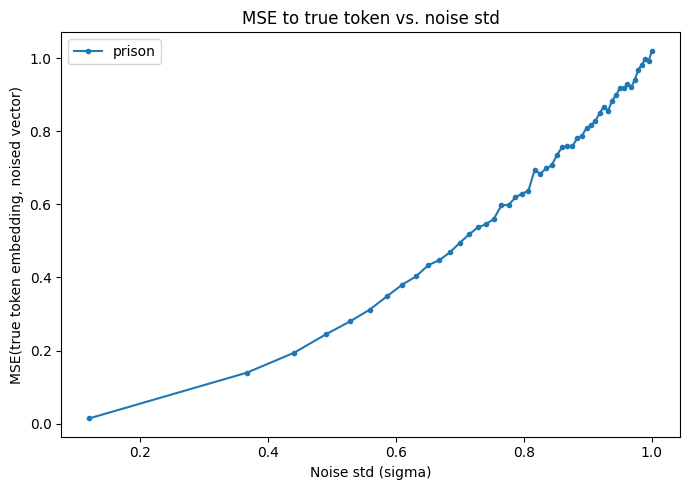

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
for word, res in all_results.items():
    ax.plot(res["sigma"], res["mean_mse"], marker="o", markersize=3, label=word)
ax.set_xlabel("Noise std (sigma)")
ax.set_ylabel("MSE(true token embedding, noised vector)")
ax.set_title("MSE to true token vs. noise std")
ax.legend()
plt.tight_layout()
#plt.savefig("/home/claude/mse_vs_noise.png", dpi=150)
plt.show()